# B3 · Transformer Attention Mechanism

Scaled dot-product attention from scratch (topic **B3** of the project catalog):
profile a CPU transformer block, find the bottleneck, and replace it — only it —
with progressively better CUDA kernels.

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | torch matmul + softmax | all-PyTorch reference: profiling *and* CPU timing baseline, every stage vectorized (MKL) |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles + one-pass softmax: reuse over redundancy |
| `GpuV3` | fused FlashAttention-1 forward | one kernel, resident Q tile, online softmax — the N×N matrix never exists |

Everything except attention — embedding, projections, norms, FFN — stays in
PyTorch on the CPU (*partial GPU principle*): only the profiled bottleneck moves.

In [1]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

One CPU model does both Stage-1 jobs. `CpuPipeline` runs every stage —
attention included — as vectorized PyTorch (MKL) ops, so the
`torch.profiler.record_function` shares reflect *algorithmic* cost, not
interpreter overhead; and its attention wall time doubles as the timing
baseline the GPU versions must beat — competent CPU code, not a strawman.

Attention is the only $O(N^2 D)$ step in the block; projections and FFN are
$O(N D^2)$, linear in N. Chart 1 shows exactly that scaling: the attention
share starts small at $N = 64$, where the FFN dominates, grows through the
FLOP-count crossover at $N \approx 5.5D \approx 2800$, and owns the forward
pass by the top of the sweep. The step that scales worst is the GPU target.

In [2]:
# Correctness gate: the CPU baseline must match torch's SDPA before it can
# serve as the profiling / timing reference.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    # unfused matmul / softmax / matmul vs fused SDPA
    torch.testing.assert_close(cpu_model(x), bench.sdpa_reference(cpu_model, x),
                               atol=1e-4, rtol=1e-3)
print("CpuPipeline matches torch.nn.functional.scaled_dot_product_attention")

CpuPipeline matches torch.nn.functional.scaled_dot_product_attention


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:14:54 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-

USDT:2026-08-05 07:14:55 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:14:55 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:14:55 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 07:14:55 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:14:55 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 07:14:57 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:14:58 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 07:15:02 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:15:06 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


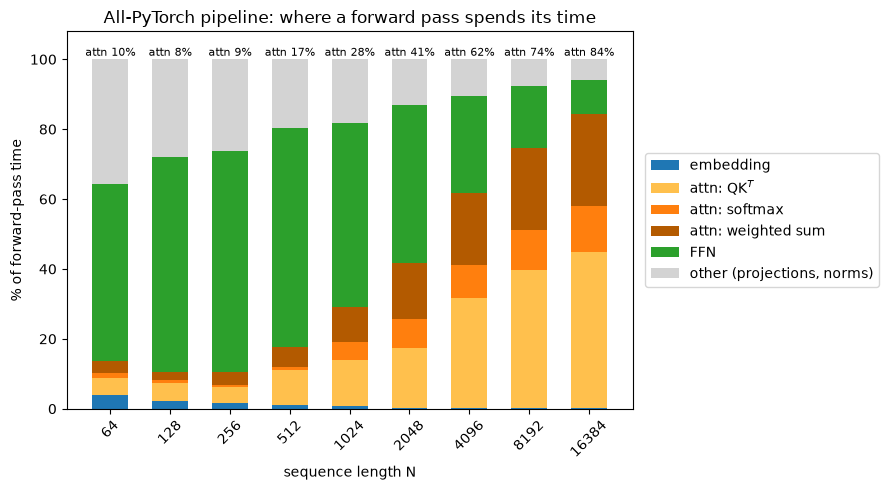

In [3]:
# Chart 1 -- share of forward-pass time per step (all-PyTorch pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 15)]
pcts = [bench.step_percentages(cpu_model, n) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("All-PyTorch pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

Three versions, one lesson each: V1 is the straight port — correct, massively
parallel, and wasteful with memory traffic; V2 shows where kernel speed
actually lives: data reuse; V3 changes the algorithm so the traffic V2 was
economising never exists at all.

**V1 — naive three-kernel** (`gpu_v1.py`): `_matmul` (QK$^T$), `_scale`,
`_softmax`, `_matmul` (weights·V) — four launches, and every intermediate
including the full N×N score matrix round-trips through global memory.
The matmul loads are coalesced (adjacent threads read adjacent addresses) but
nothing is reused, and the softmax uses one block per row with a coalesced
read but still passes over the row three times (max, sum, write); V2 folds
those into one pass.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from global
memory 16× less often; shared arrays are padded to dodge bank conflicts) and fuses
the $1/\sqrt{D}$ scaling into the epilogue. `_softmax_online` uses one block
per row: a running (max, sum) pair rescaled when the max moves — the
log-sum-exp trick — gets both out of **one** coalesced read of the row.

**V3 — fused FlashAttention-1 forward** (`gpu_v3.py`): the whole step in one
kernel, and the $N \times N$ score matrix never exists in any memory. Each
block stages its 16-row Q tile in shared memory *once* and keeps it resident
while sweeping the K/V tiles — Q traffic drops from $O(N^2 D)$ to $O(N D)$.
Per 16×16 tile: the score tile $S = QK^T/\sqrt{D}$ is a shared-memory block
matmul (K and V staged chunk by chunk with exactly V2's tiling idiom — no
prefetching, no unrolling); then Algorithm 1 of the FlashAttention paper
runs verbatim — the tile's row max $\tilde{m}$ and sum $\tilde{l}$ merge
into the running $(m, l)$, and the output block is rescaled *and
renormalised* on the spot, so it always holds the exact softmax-weighted sum
of every key seen so far. Where V2 economised the N×N traffic, V3 deletes
it — at the price of one rescale-divide per tile, which FA-2 later showed
how to defer.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [4]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2, GpuV3):
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV1: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV2: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV3: matches torch SDPA within 1e-4


### Distribution shift — the bottleneck moves back

Same buckets for all four pipelines: attention as a single step, since the
GPU versions don't split it into sub-steps (and their attention time includes
the CPU↔GPU transfers — the honest cost of the swap); the all-PyTorch panel
reuses Chart 1's measurements. Moving attention to the GPU flips Chart 1: the
$O(N^2)$ step drops out of the distribution and the forward pass belongs to
the linear PyTorch steps again — until the $O(N^2)$ kernel time starts
creeping back in at the top of the sweep, the same scaling argument one level
down. V1, V2 and V3 differ only in the attention band, so each faster kernel
is directly visible as a thinner orange stripe.

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 0

USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 07:15:08 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:15:09 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 07:15:10 831270:831270 ActivityProfilerController.cpp:415] profiler_start


...

USDT:2026-08-05 07:15:23 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 07:15:23 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:15:24 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 07:15:26 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:15:28 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


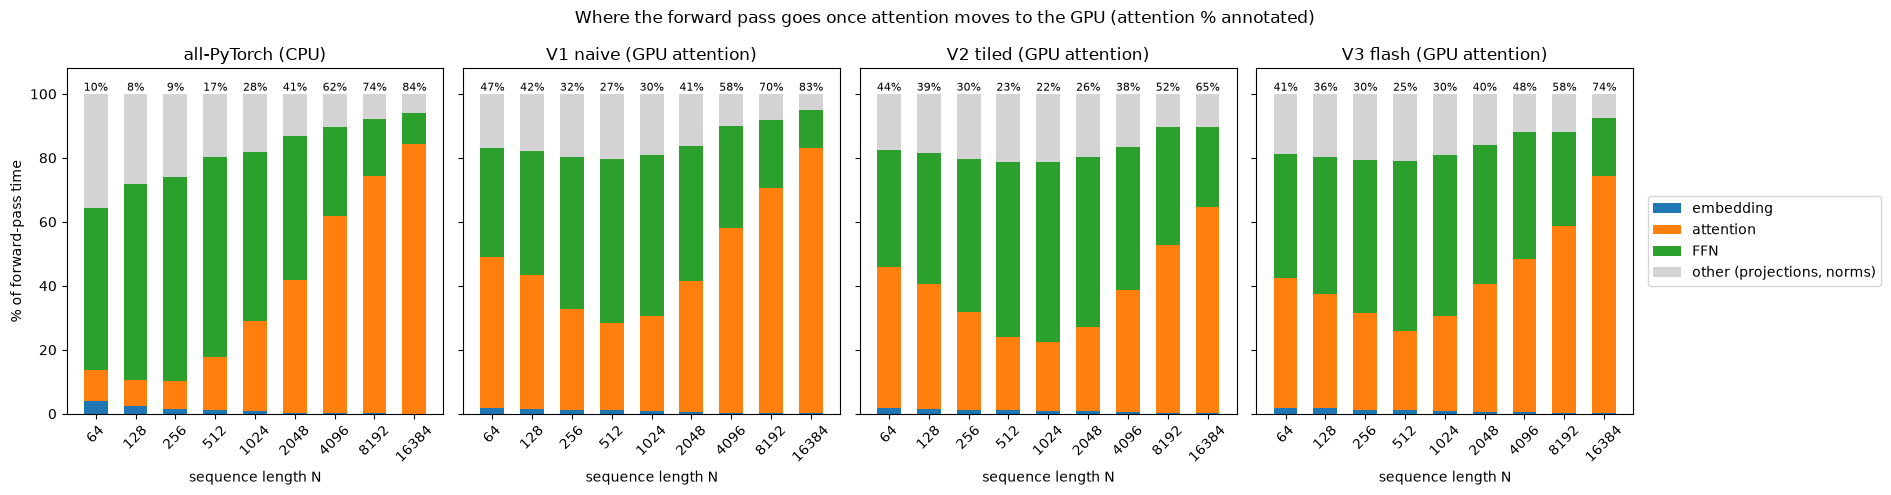

In [5]:
# Chart 1b -- step-time distribution per pipeline (coarse buckets, all comparable)
if cuda.is_available():
    # torch panel reuses Chart 1's profile: the sub-steps sum to the attention total
    dist = {"all-PyTorch (CPU)": [
        {"1_embedding": p["1_embedding"],
         "2_attention_total": sum(p[s] for s in bench.ATTN_STEPS),
         "3_ffn": p["3_ffn"], "other": p["other"]} for p in pcts]}
    for title, m in (("V1 naive (GPU attention)", GpuV1().eval()),
                     ("V2 tiled (GPU attention)", GpuV2().eval()),
                     ("V3 flash (GPU attention)", GpuV3().eval())):
        dist[title] = [bench.step_percentages(m, n, steps=bench.STEPS_TOTAL)
                       for n in PROFILE_LENS]
    torch.cuda.empty_cache()  # drop the dead N x N blocks the GPU passes leave cached

    parts = bench.STEPS_TOTAL + ["other"]
    names = {"1_embedding": "embedding", "2_attention_total": "attention",
             "3_ffn": "FFN", "other": "other (projections, norms)"}
    colors = {"1_embedding": "tab:blue", "2_attention_total": "tab:orange",
              "3_ffn": "tab:green", "other": "lightgray"}

    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(PROFILE_LENS))
    for ax, (title, ps) in zip(axes, dist.items()):
        bottom = np.zeros(len(PROFILE_LENS))
        for part in parts:
            vals = np.array([p[part] for p in ps])
            ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
            bottom += vals
        for xi, p in zip(xpos, ps):  # annotate the attention share
            ax.text(xi, 101, f"{p['2_attention_total']:.0f}%", ha="center", fontsize=8)
        ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.set_ylim(0, 108)
    axes[0].set_ylabel("% of forward-pass time")
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.suptitle("Where the forward pass goes once attention moves to the GPU (attention % annotated)")
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the combined step-share chart")

## Benchmark — attention step time

Timings cover the attention step only, on precomputed q, k, v. The GPU
columns *include* the CPU→GPU→CPU transfers — the true cost of swapping a
kernel into an otherwise-CPU pipeline. N sweeps the powers of two from $2^6$
to $2^{14}$ (64 → 16384), covering every spec checkpoint (128 / 512 / 2048)
and running well past the $N \approx 5.5D$ crossover where attention owns
the forward pass. The CPU baseline is the same attention as three vectorized
torch/MKL ops on the same four cores — one warm profiled pass per point,
which also yields the sub-step times reused as Chart 2's baselines. The top
of the sweep is a memory wall, not a time wall: the unfused N×N score and
weight matrices cost ~2–3 GB of RAM at N = 16384 and 4× that at the next
doubling, and V1/V2's GPU intermediates track the same growth (Chart 4).

In [6]:
SEQ_LENS = [2 ** x for x in range(6, 15)]

if cuda.is_available():
    classes = {"V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               "V3 flash fused": GpuV3,
               }
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    times["torch SDPA (GPU)"] = [bench.sdpa_gpu_ms(cpu_model, n, reps=3) for n in SEQ_LENS]
    torch.cuda.empty_cache()  # drop cached blocks so the sweep leaves no footprint

    # CPU baseline: the same attention as three vectorized torch/MKL ops on
    # the same cores — one warm profiled pass per point yields the sub-step
    # times (Chart 2's baselines) and their sum, the CPU column
    cpu_model.attention(*bench._qkv(cpu_model, 64))  # warm MKL / thread pool
    cpu_steps = [bench.attention_step_ms(cpu_model, n) for n in SEQ_LENS]
    times = {"CPU": [sum(d.values()) for d in cpu_steps], **times}

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"CPU": "tab:red",
          "V1 naive": "tab:blue", "V2 tiled + online softmax": "tab:orange",
          "V3 flash fused": "tab:green", "torch SDPA (GPU)": "gray"}

USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05

USDT:2026-08-05 07:15:59 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:16:00 831270:831270 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 07:16:00 831270:831270 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 07:16:01 831270:831270 ActivityProfilerController.cpp:415] profiler_start


     N                          CPU                    V1 naive   V2 tiled + online softmax              V3 flash fused            torch SDPA (GPU)
---------------------------------------------------------------------------------------------------------------------------------------------------
    64                      0.71 ms                     2.01 ms                     1.70 ms                     1.23 ms                     0.57 ms
   128                      0.57 ms                     2.22 ms                     1.95 ms                     1.65 ms                     0.71 ms
   256                      1.03 ms                     2.74 ms                     2.38 ms                     2.43 ms                     1.11 ms
   512                      2.82 ms                     4.22 ms                     3.55 ms                     4.00 ms                     1.88 ms
  1024                      9.74 ms                    10.26 ms                     6.33 ms                    1

USDT:2026-08-05 07:16:04 831270:831270 ActivityProfilerController.cpp:455] profiler_stop


## Attention kernel timing — compute only

How fast are the kernels once the transfers are taken out of the picture?
Following the HW02 methodology: **device-resident timing with CUDA events**, so
the timed region is pure compute — no CPU→GPU→CPU copy. This isolates kernel
speed from the pipeline-boundary tax that the end-to-end sweep pays.

In [7]:
# Kernel-only timing sweep (CUDA events, device-resident)
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs")

    kmodels = {"V1 naive": GpuV1().eval(),
               "V2 tiled + online softmax": GpuV2().eval(),
               "V3 flash fused": GpuV3().eval(),
               }
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=10) for n in SEQ_LENS]
              for name, m in kmodels.items()}
    ktimes["torch SDPA (GPU)"] = [bench.sdpa_kernel_ms(cpu_model, n, reps=10)
                                  for n in SEQ_LENS]
    # per-step kernel times (QK^T, softmax, weighted sum) for Chart 3 --
    # only the unfused versions expose the three step methods (V3 is one kernel)
    ksteps = {name: [bench.attention_kernel_step_ms(m, n, reps=10) for n in SEQ_LENS]
              for name, m in kmodels.items() if "_step_qkt" in type(m).__dict__}
    torch.cuda.empty_cache()  # drop the dead N x N blocks V1/V2 leave cached

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: Tesla T4 | 40 SMs



     N                      V1 naive     V2 tiled + online softmax                V3 flash fused              torch SDPA (GPU)   (kernel-only ms)
------------------------------------------------------------------------------------------------------------------------------
    64                      1.469 ms                      1.299 ms                      0.688 ms                      0.187 ms
   128                      1.487 ms                      1.273 ms                      0.664 ms                      0.176 ms
   256                      1.489 ms                      1.289 ms                      0.932 ms                      0.182 ms
   512                      1.776 ms                      1.287 ms                      1.708 ms                      0.178 ms
  1024                      7.971 ms                      3.057 ms                      7.396 ms                      0.491 ms
  2048                     35.874 ms                     14.294 ms                     28.7

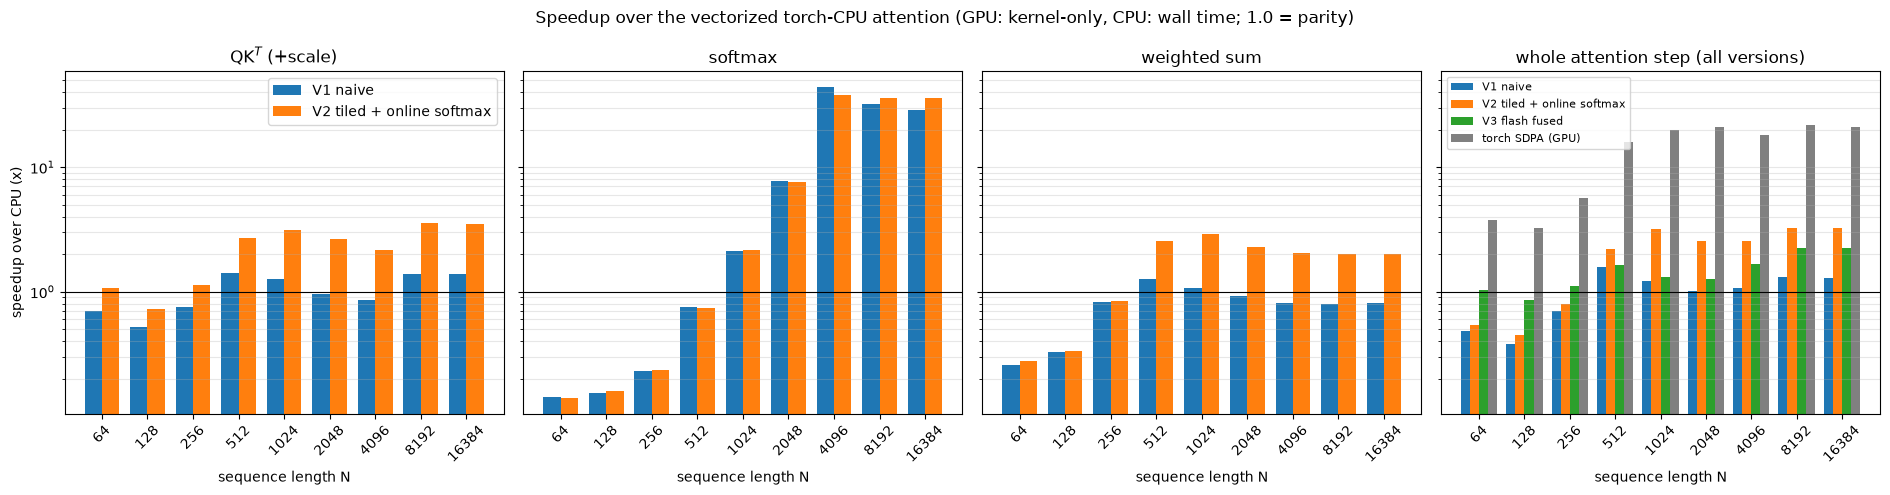

In [8]:
# Chart 2 -- speedup over the CPU baseline (vectorized torch): per sub-step
# for the unfused GPU versions, then the whole step for all four (V3 and
# torch SDPA are single fused kernels, so whole-step granularity only)
if cuda.is_available():
    step_names = {"2a_qk_matmul": "QK$^T$ (+scale)", "2b_softmax": "softmax",
                  "2c_value_weighted_sum": "weighted sum"}
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(SEQ_LENS))
    w = 0.76 / len(ksteps)
    offs = (np.arange(len(ksteps)) - (len(ksteps) - 1) / 2) * w
    for ax, (step, title) in zip(axes, step_names.items()):
        for off, (name, ks) in zip(offs, ksteps.items()):
            speedups = [c[step] / g[step] for c, g in zip(cpu_steps, ks)]
            ax.bar(xpos + off, speedups, w, color=COLORS[name], label=name)
        ax.set_yscale("log")
        ax.axhline(1.0, color="k", lw=0.8)
        ax.set_xticks(xpos, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, axis="y", which="both", alpha=0.3)

    ax = axes[-1]
    cpu_total = [sum(c.values()) for c in cpu_steps]
    w4 = 0.8 / len(ktimes)
    offs4 = (np.arange(len(ktimes)) - (len(ktimes) - 1) / 2) * w4
    for off, (name, kt) in zip(offs4, ktimes.items()):
        speedups = [c / g for c, g in zip(cpu_total, kt)]
        ax.bar(xpos + off, speedups, w4, color=COLORS[name], label=name)
    ax.set_yscale("log")
    ax.axhline(1.0, color="k", lw=0.8)
    ax.set_xticks(xpos, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_title("whole attention step (all versions)")
    ax.grid(True, axis="y", which="both", alpha=0.3)
    ax.legend(fontsize=8)

    axes[0].set_ylabel("speedup over CPU (x)")
    axes[0].legend()
    plt.suptitle("Speedup over the vectorized torch-CPU attention "
                 "(GPU: kernel-only, CPU: wall time; 1.0 = parity)")
    plt.tight_layout()
    plt.show()

## Memory traffic — measured DRAM bytes

What actually crosses the DRAM boundary during one attention pass, from
Nsight Compute's `dram__bytes.sum` — every transaction counted, refetches
included, cache hits excluded. The counters are root-gated, so
`src/dram_profile.py collect` runs once under sudo and caches
`dram_profile.json`; the cell reuses the cache (and collects itself where
counters are reachable). The dotted line is the compulsory floor — Q, K, V
read once, output written once (`bench.attention_bytes`) — the bytes no
implementation can avoid.

The measurement shows two things no byte model would. Below the L2 spill
(the N×N working set passes the T4's 4 MB around N = 2048) every version
hugs the floor — the redundancy never reaches the DRAM pins. Past it, the
unfused round-trips compound with N: by N = 16384, V1 and V2 each move
~130–140 GB per pass against a 134 MB floor (~1000×) — near-identical
totals, because V2's 16× tiling cut is served from shared memory, an
on-chip win invisible at this boundary — and torch SDPA's materialised N×N
costs 14.8 GB (110×). V3 stays at 3.6 GB (27× the floor, 36× fewer bytes
than V2): FlashAttention's fewer-HBM-accesses claim, measured. The table
derives achieved bandwidth and utilization from the same rows — one caveat:
ncu locks the GPU to base clocks while profiling (durations run ~2.3× the
boost-clock CUDA-event sweep; bytes are clock-independent). No version
saturates the bus — the workload is compute-side (Chart 5) — but by the top
of the sweep V2's traffic bill is real: 128 GB over its 1.04 s boost-clock
kernel time is ~124 GB/s against the ~320 GB/s peak.

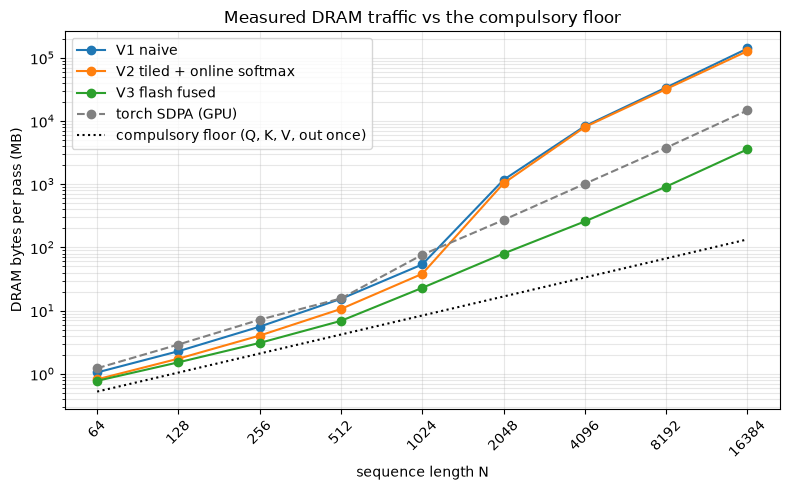

                   version      N    measured  floor x  kernel ms    GB/s  %peak
                  V1 naive  16384   140815 MB  1049.2x   4542.843    31.0   9.7%
 V2 tiled + online softmax  16384   128230 MB   955.4x   1970.320    65.1  20.3%
            V3 flash fused  16384     3577 MB    26.7x   3477.457     1.0   0.3%
          torch SDPA (GPU)  16384    14771 MB   110.1x    219.704    67.2  21.0%


In [9]:
# Chart 3 -- measured DRAM traffic per attention pass (ncu dram__bytes.sum)
# vs the compulsory floor; derived bandwidth/utilization in the table below.
if cuda.is_available():
    import json, os, subprocess, sys
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    if not prof_path.exists():  # counters are root-gated: one-off sudo step
        cmd = ([] if os.geteuid() == 0 else ["sudo", "-n"]) + \
              [sys.executable, "src/dram_profile.py", "collect"]
        try:
            subprocess.run(cmd, check=True)
        except (subprocess.CalledProcessError, FileNotFoundError, PermissionError):
            print("no dram_profile.json and no counter access here -- run:")
            print("  sudo .venv/bin/python src/dram_profile.py collect")

    if prof_path.exists():
        prof = json.loads(prof_path.read_text())
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused", "sdpa": "torch SDPA (GPU)"}
        fig, ax = plt.subplots(figsize=(8, 5))
        for key, rows in prof.items():
            name = pnames[key]
            ax.plot([r["n"] for r in rows], [r["dram_bytes"] / 1e6 for r in rows],
                    marker="o", color=COLORS[name],
                    linestyle="--" if "SDPA" in name else "-", label=name)
        ax.plot(SEQ_LENS, [bench.attention_bytes(cpu_model, n) / 1e6 for n in SEQ_LENS],
                "k:", label="compulsory floor (Q, K, V, out once)")
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_ylabel("DRAM bytes per pass (MB)")
        ax.set_title("Measured DRAM traffic vs the compulsory floor")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        bw = bench.gpu_specs()["bw_gbs"]
        print(f"{'version':>26} {'N':>6} {'measured':>11} {'floor x':>8} "
              f"{'kernel ms':>10} {'GB/s':>7} {'%peak':>6}")
        for key, rows in prof.items():
            r = rows[-1]  # largest N
            gbs = r["dram_bytes"] / (r["kernel_ms"] / 1e3) / 1e9
            floor = bench.attention_bytes(cpu_model, r["n"])
            print(f"{pnames[key]:>26} {r['n']:>6} {r['dram_bytes'] / 1e6:>8.0f} MB "
                  f"{r['dram_bytes'] / floor:>7.1f}x {r['kernel_ms']:>10.3f} "
                  f"{gbs:>7.1f} {gbs / bw * 100:>5.1f}%")
else:
    print("No CUDA device -- skipping the DRAM traffic chart")

## Memory footprint — the O(N²) wall

Traffic explains speed; footprint decides feasibility. The unfused versions
materialise the N×N score and weight matrices — 2·N²·4 bytes beyond the
inputs — while V3 streams tiles and allocates only the [N, D] output.
Footprint needs no CPU baseline, so this sweep runs past the timing cap
until the quadratic versions stop fitting on the card; the wall is measured
(torch allocator high-water mark, OOM caught), not modelled.

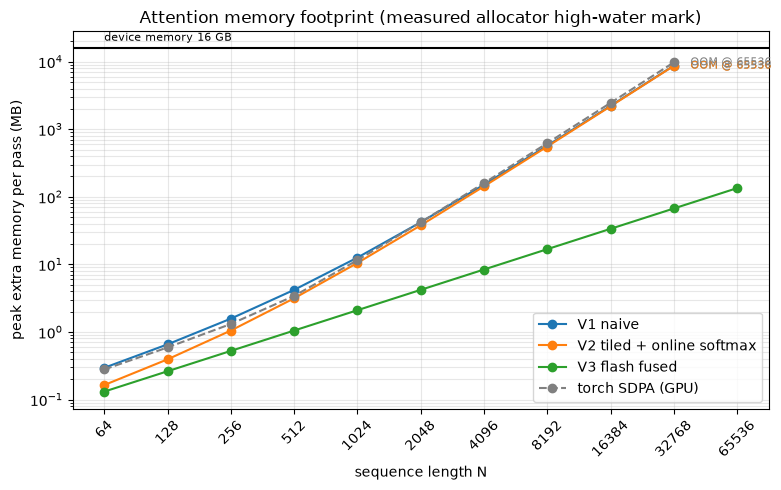

                  V1 naive: fits to N = 32768, OOM at N = 65536
 V2 tiled + online softmax: fits to N = 32768, OOM at N = 65536
            V3 flash fused: fits to N = 65536
          torch SDPA (GPU): fits to N = 32768, OOM at N = 65536


In [10]:
# Chart 4 -- peak extra GPU memory of one attention pass, swept until the
# O(N^2) versions hit the card's capacity. None (OOM) ends a line.
if cuda.is_available():
    FOOT_LENS = [2 ** x for x in range(6, 17)]  # 64 .. 65536
    foot_models = {"V1 naive": GpuV1(), "V2 tiled + online softmax": GpuV2(),
                   "V3 flash fused": GpuV3()}
    foot = {name: [] for name in [*foot_models, "torch SDPA (GPU)"]}
    for n in FOOT_LENS:
        for name, m in foot_models.items():
            foot[name].append(bench.attention_peak_extra_bytes(m, n))
        foot["torch SDPA (GPU)"].append(bench.sdpa_peak_extra_bytes(cpu_model, n))
        torch.cuda.empty_cache()

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, vals in foot.items():
        pts = [(n, b) for n, b in zip(FOOT_LENS, vals) if b is not None]
        xs, ys = [p[0] for p in pts], [p[1] / 1e6 for p in pts]
        ax.plot(xs, ys, marker="o", color=COLORS[name],
                linestyle="--" if "SDPA" in name else "-", label=name)
        if len(pts) < len(FOOT_LENS):  # line ends where the alloc stopped fitting
            ax.text(xs[-1] * 1.2, ys[-1], f"OOM @ {FOOT_LENS[len(pts)]}",
                    color=COLORS[name], fontsize=8, va="center")
    total = torch.cuda.get_device_properties(0).total_memory
    ax.axhline(total / 1e6, color="k", lw=1.5)
    ax.text(FOOT_LENS[0], total / 1e6 * 1.3, f"device memory {total / 1e9:.0f} GB",
            fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(FOOT_LENS, FOOT_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("peak extra memory per pass (MB)")
    ax.set_title("Attention memory footprint (measured allocator high-water mark)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    for name, vals in foot.items():
        fit = sum(b is not None for b in vals)
        print(f"{name:>26}: fits to N = {FOOT_LENS[fit - 1]}"
              + ("" if fit == len(FOOT_LENS) else f", OOM at N = {FOOT_LENS[fit]}"))
else:
    print("No CUDA device -- skipping the footprint sweep")

## Compute — executed FLOPs

The same measurement discipline as Chart 3, applied to arithmetic: Nsight
Compute's SASS thread-instruction counters give the fp32 operations each
implementation actually executed (fadd + fmul + 2·ffma, predicated-on lanes
only; collected into `dram_profile.json` alongside the bytes). The dotted
line is the algorithmic floor — the two matmuls' $4N^2D$ FLOPs from torch's
`flop_counter`, identical for every version by construction. The gap above
it is implementation overhead: V1's separate scale pass and three-pass
softmax, V2's leaner one-pass softmax, and V3's per-tile
rescale-and-renormalise — the non-matmul FLOPs that FA-2's deferred
normalisation later removed. (`exp()` runs on the SFU, which Turing exposes
no per-op counter for, so it is absent from the FLOP line for everyone.)

The chart plots the count as a ratio to the floor — the raw GFLOP curves
overlap indistinguishably on any shared axis, which is itself the punchline:
at D = 512 every version executes within ~2% of the floor (V3's per-tile
renormalisation, at ~8%, is the only visible overhead), while Chart 3
spreads the same versions across 70× in bytes — this workload's implementations differ in
memory behaviour, not arithmetic. The table derives throughput the
conventional way (floor FLOPs over boost-clock kernel time) against the
fp32 ceiling; Turing has no fp32 tensor-core path, so the ceiling is the
CUDA-core one.

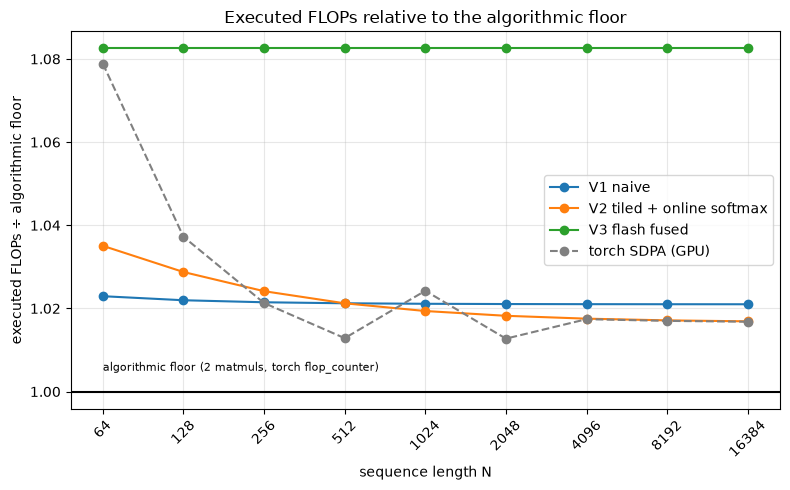

                   version      N      executed  floor x  TFLOP/s  %peak   (throughput = floor FLOPs / kernel-sweep ms)
                  V1 naive  16384  561.30 GFLOP   1.021x     0.21   2.6%
 V2 tiled + online softmax  16384  559.04 GFLOP   1.017x     0.53   6.5%
            V3 flash fused  16384  595.12 GFLOP   1.083x     0.37   4.6%
          torch SDPA (GPU)  16384  558.99 GFLOP   1.017x     3.43  42.1%


In [11]:
# Chart 5 -- executed fp32 FLOPs per pass (ncu SASS thread-instruction
# counters: fadd + fmul + 2*ffma) as a ratio to the algorithmic floor (torch
# flop_counter's two matmuls). Raw counts overlap on any shared axis -- the
# ratio makes the few-percent overheads legible. Throughput in the table.
if cuda.is_available():
    import json
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    prof = json.loads(prof_path.read_text()) if prof_path.exists() else {}
    if not prof or "flops" not in prof["v1"][0]:
        print("dram_profile.json lacks FLOP counters -- regenerate with:")
        print("  sudo .venv/bin/python src/dram_profile.py collect")
    else:
        pnames = {"v1": "V1 naive", "v2": "V2 tiled + online softmax",
                  "v3": "V3 flash fused", "sdpa": "torch SDPA (GPU)"}
        floor = {n: bench.attention_flops(cpu_model, n) for n in SEQ_LENS}
        fig, ax = plt.subplots(figsize=(8, 5))
        for key, rows in prof.items():
            ax.plot([r["n"] for r in rows],
                    [r["flops"] / floor[r["n"]] for r in rows],
                    marker="o", color=COLORS[pnames[key]],
                    linestyle="--" if key == "sdpa" else "-", label=pnames[key])
        ax.axhline(1.0, color="k", lw=1.5)
        ax.text(SEQ_LENS[0], 1.005, "algorithmic floor (2 matmuls, torch flop_counter)",
                fontsize=8)
        ax.set_xscale("log", base=2)
        ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_ylabel("executed FLOPs ÷ algorithmic floor")
        ax.set_title("Executed FLOPs relative to the algorithmic floor")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        specs = bench.gpu_specs()
        print(f"{'version':>26} {'N':>6} {'executed':>13} {'floor x':>8} "
              f"{'TFLOP/s':>8} {'%peak':>6}   (throughput = floor FLOPs / kernel-sweep ms)")
        for key, rows in prof.items():
            r = rows[-1]  # largest N
            tflops = floor[r["n"]] / (ktimes[pnames[key]][-1] / 1e3) / 1e12
            print(f"{pnames[key]:>26} {r['n']:>6} {r['flops'] / 1e9:>7.2f} GFLOP "
                  f"{r['flops'] / floor[r['n']]:>7.3f}x {tflops:>8.2f} "
                  f"{100 * tflops / specs['tflops']:>5.1f}%")
else:
    print("No CUDA device -- skipping the FLOP chart")

## Conclusion

Chart 1 picked the target — attention is the only step whose share of the
forward pass grows with N, and the sweep now runs through the
$N \approx 5.5D \approx 2800$ crossover where it overtakes every linear
step — and replacing just that step takes N = 16384 attention from ~3.3 s
on the vectorized CPU baseline to ~1.0 s with V2, transfers included
(~3.2×; V3 lands ~2.2×, naive V1 ~1.3× — and V1 doesn't beat the CPU at
all until N = 4096). These are honest numbers against competent CPU code:
a T4's fp32 pipes against four MKL cores buy single-digit factors, and the
ladder's real target, torch SDPA (GPU), reaches ~20×.

The kernel ladder is a memory story told twice. Chart 2 shows the speed
rungs: V1 is coalesced but reuse-free — every matmul operand is re-read
from global memory per output element; V2's 16×16 shared-memory tiles
request ~16× fewer bytes for the same math and its one-pass online softmax
replaces V1's three passes over the row — ~2.5× over V1 kernel-to-kernel
and the fastest handwritten kernel from N = 512 up. Chart 3 measures what
tiling does and doesn't change: past the L2 spill at N = 2048 the unfused
round-trips compound, and by N = 16384 V1 and V2 each drag ~130–140 GB of
DRAM traffic per pass against a 134 MB floor — tiling cut on-chip requests,
not DRAM bytes. V3 — the FlashAttention-1 forward: resident Q tile, one
fused kernel, per-tile online softmax that rescales and renormalises the
running output — deletes the N×N traffic instead: 3.6 GB at N = 16384, 27×
the floor, 36× fewer bytes than V2. It pays for fusion in kernel time
(1.48 vs 1.04 s at N = 16384: ahead of V1 everywhere, behind V2 past
N = 256 — the per-tile rescale-divides, measured by Chart 5 as 1.08× the
FLOP floor against V2's 1.02×, plus the 33 KB resident tile's
one-block-per-SM occupancy, are the price) and collects in memory: Chart
4's footprint stays O(N), and at N = 65536 the N×N matrices OOM V1, V2 and
torch SDPA alike on the 16 GB card — V3 is the only version still standing.

The remaining gap to torch SDPA is a lesson about *levels* of optimization.
SDPA here is the math backend — algorithmically identical to V2, N×N
materialised and all (it hits the same OOM wall) — but its matmuls are
cuBLAS SGEMM: register micro-tiles, vectorized loads, software-pipelined
staging, 42–62% of fp32 peak where our tiled kernels reach ~7% (Turing has
no fp32 tensor-core path, so the gap is pure scheduling, not special
hardware). And fusion cannot be composed from library calls — handing
cuBLAS the matmuls means materialising N×N, which is exactly what V3 exists
to avoid — so a fused kernel must bring its own matmul, and numba's scalar
fp32 pipeline pays ~8× for it. That is the whole trade, measured: on fp16
tensor-core hardware, where flash kernels exist, the balance inverts and
fusion wins outright; on a T4 at fp32, the ladder ends where the
programming model does.